# Tech Challenge 1 — Classificação de Câncer de Mama

**Dataset:** Wisconsin Breast Cancer (Kaggle / UCI ML Repository) ([Link](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data))  
**Objetivo:** Classificar tumores mamários como **Benigno (B)** ou **Maligno (M)** com base em 30 características numéricas extraídas de imagens de biópsia por aspiração de agulha fina (FNA).

Link do Vídeo Explicativo: https://youtu.be/IPdttGBSu9U

Link do GitHub do projeto: https://github.com/rafaellareis20/projeto-IADT-colab

**Grupo:**

Gabriel Paoliello RM370704 - `ga.paoliello@gmail.com`

Pedro Rogala RM372338 - `pedrorogala@gmail.com`

Sandro Felipe RM372111 - `kleyguerth@gmail.com`

Rafaella Reis RM373710 - `rafaelareis20@gmail.com`

Wisley Siqueira RM374052 - `dev.wisleysiqueira@gmail.com`


---

## Estrutura do Notebook

| Seção | Descrição |
|---|---|
| 1. Coleta e Carregamento | Download e leitura do dataset via Kaggle |
| 2. Análise Exploratória (EDA) | Inspeção inicial, balanceamento e valores ausentes |
| 3. Pré-processamento | Limpeza, codificação e normalização dos dados |
| 4. Visualização | Correlações, distribuições e boxplots por classe |
| 5. Modelagem — 30 features | Validação cruzada com 4 classificadores |
| 6. Ajuste de Hiperparâmetros | GridSearchCV no melhor modelo |
| 7. Avaliação Final | Métricas, matriz de confusão e curva ROC |
| 8. Subconjunto de Features | Análise com features `_worst` filtradas por correlação |
| 9. Conclusão | Resumo dos resultados e principais aprendizados |

---
## 1. Coleta e Carregamento dos Dados

O dataset é baixado diretamente do Kaggle via `kagglehub`. São importadas também todas as bibliotecas necessárias para análise, pré-processamento e modelagem.

In [ ]:
import os
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold,
                                     cross_val_score, cross_validate, GridSearchCV)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay)

In [ ]:
# Download da versão mais recente do dataset
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Caminho do dataset:", path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Caminho do dataset: /kaggle/input/breast-cancer-wisconsin-data


### 1.1 Leitura do Dataset

Os arquivos disponíveis no diretório do dataset são listados e o CSV principal é carregado em um DataFrame.

In [ ]:
# Listar arquivos no diretório do dataset
files = os.listdir(path)
print("Arquivos encontrados:", files)

# Carregar o arquivo CSV principal
file_path = os.path.join(path, files[0])
df_breast_cancer = pd.read_csv(file_path)
RANDOM_STATE = 156

Arquivos encontrados: ['data.csv']


---
## 2. Análise Exploratória de Dados (EDA)

### 2.1 Dimensões do Dataset

Verificamos o número de amostras (linhas) e de atributos (colunas) disponíveis.

In [ ]:
df_breast_cancer.shape

(569, 33)

### 2.2 Colunas Disponíveis

Listagem de todas as colunas do dataset, incluindo o identificador, a variável alvo e as 30 features numéricas.

In [ ]:
df_breast_cancer.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

### 2.3 Amostra dos Dados

Visualização do DataFrame para entender as colunas, os tipos de dados e os valores presentes no dataset.

In [ ]:
df_breast_cancer

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


### 2.4 Estatísticas Descritivas

Resumo estatístico das colunas numéricas: contagem, média, desvio padrão, mínimo, máximo e quartis. Útil para identificar diferenças de escala, possíveis outliers e distribuições assimétricas.

In [ ]:
df_breast_cancer.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


### 2.5 Verificação de Valores Ausentes

Não foram encontrados valores nulos nas features preditivas. A coluna `Unnamed: 32` é um artefato do arquivo CSV — contém apenas valores `NaN` e será removida no pré-processamento. A coluna `id` (identificador do paciente) também será removida por não ter relação com o diagnóstico.

In [ ]:
df_breast_cancer.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


### 2.6 Verificação da Variável Alvo

Confirmamos que a coluna `diagnosis` contém apenas os dois valores esperados: `B` (Benigno) e `M` (Maligno).

In [ ]:
set(df_breast_cancer['diagnosis'])

{'B', 'M'}

Apenas os valores `B` e `M` foram encontrados — nenhum tratamento adicional é necessário na variável alvo.

### 2.7 Balanceamento de Classes

Verificamos a proporção entre as classes para avaliar o grau de desbalanceamento.

/tmp/ipykernel_1389/4152368848.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df_breast_cancer, palette='viridis')


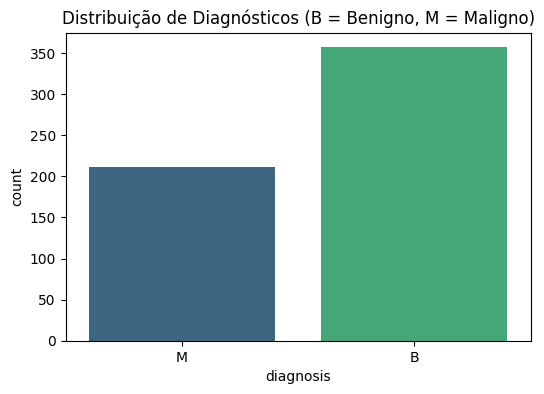

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df_breast_cancer, palette='viridis')
plt.title('Distribuição de Diagnósticos (B = Benigno, M = Maligno)')
plt.show()

print(df_breast_cancer['diagnosis'].value_counts(normalize=True) * 100)

O dataset apresenta aproximadamente 63% de amostras Benignas e 37% Malignas. O desbalanceamento moderado (~2:1) não exige técnicas de reamostragem. Utilizaremos o **ROC-AUC** como métrica principal de avaliação, pois é mais robusto a desbalanceamentos do que a acurácia simples.

---
## 3. Pré-processamento

### 3.1 Remoção de Colunas Não Preditivas

Removemos as colunas que não contribuem para o aprendizado do modelo:
- **`Unnamed: 32`**: coluna completamente vazia, artefato do CSV.
- **`id`**: identificador único do paciente, sem relação com o diagnóstico.

In [ ]:
df_breast_cancer.drop('Unnamed: 32', axis=1, inplace=True)
df_breast_cancer.drop('id', axis=1, inplace=True)

### 3.2 Codificação da Variável Alvo

Codificamos `diagnosis` para formato numérico com `LabelEncoder`: `B → 0` (Benigno) e `M → 1` (Maligno). Essa transformação é necessária para os algoritmos de machine learning.

In [ ]:
lEncoder = LabelEncoder()

df_num_diag = df_breast_cancer.copy(deep=True)
df_num_diag['diagnosis'] = lEncoder.fit_transform(df_num_diag['diagnosis'])

for index, klass in enumerate(lEncoder.classes_):
  print(f"{klass} -> {index}")

B -> 0
M -> 1


### 3.3 Normalização das Features (StandardScaler)

Aplicamos `StandardScaler` em todas as 30 features numéricas, transformando-as para média zero e desvio padrão um. Essa etapa é essencial para algoritmos sensíveis à escala, como SVM, KNN e Regressão Logística.

In [ ]:
# Separando features (X) da variável alvo (y)
X = df_num_diag.drop('diagnosis', axis=1)
y = df_num_diag['diagnosis']

# Ajuste e transformação das features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DataFrame com features normalizadas e variável alvo
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled['diagnosis'] = y

In [ ]:
df_scaled

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,1
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,1
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,1
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,1
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,...,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091,1
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,...,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978,1
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,...,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409,1
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,...,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635,1


---
## 4. Visualização e Análise de Features

### 4.1 Matriz de Correlação

A matriz de correlação revela as relações lineares entre todas as features e com a variável alvo. Grupos de features altamente correlacionadas entre si (como `radius_mean`, `perimeter_mean` e `area_mean`) indicam redundância — informação relevante para seleção de features.

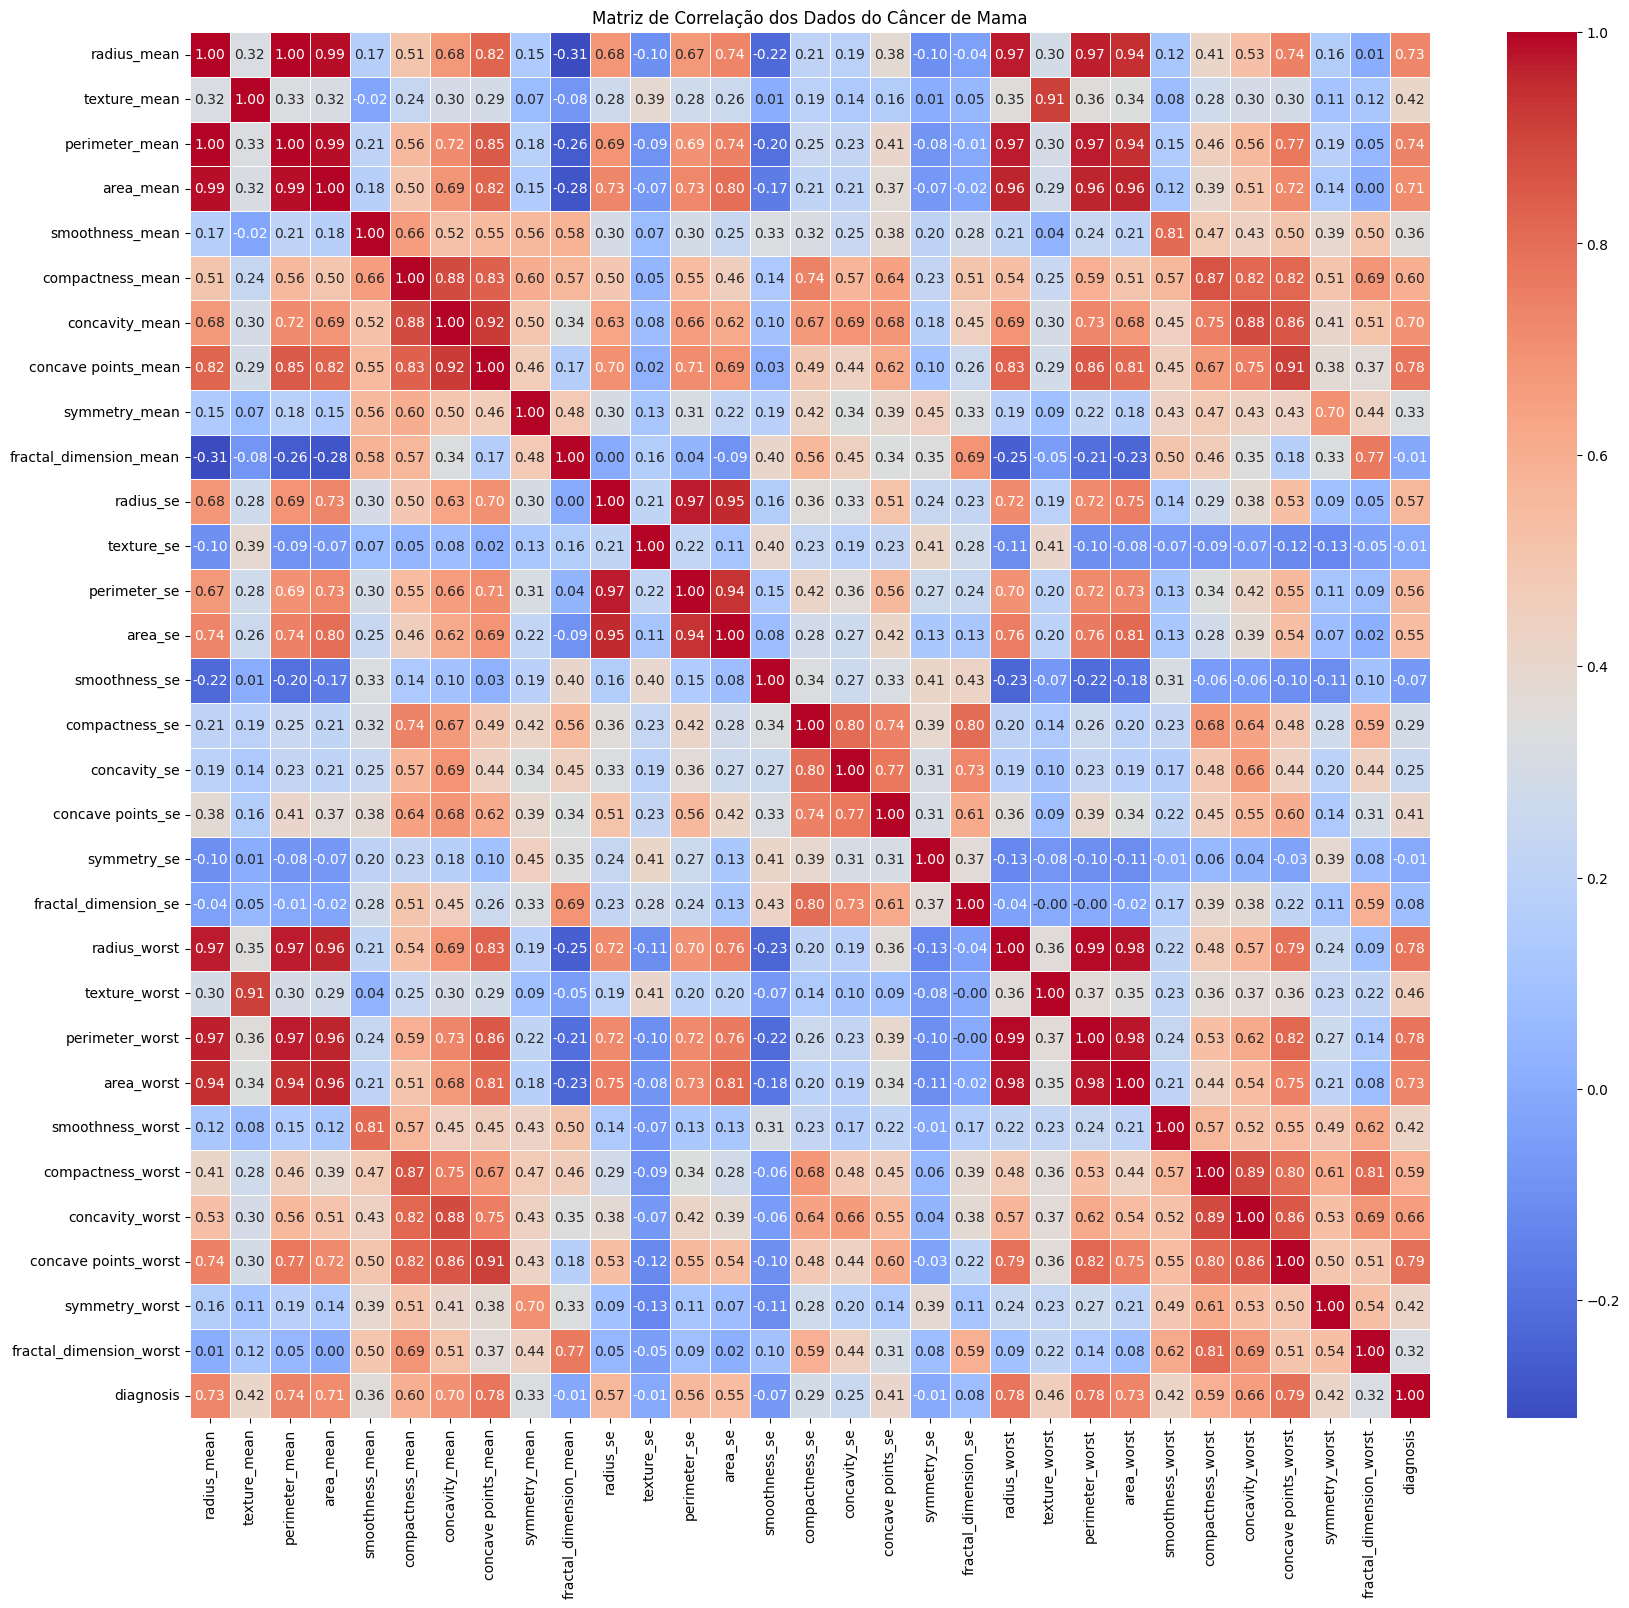

In [ ]:
correlation_matrix = df_scaled.select_dtypes(include=['number']).corr()

plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação dos Dados do Câncer de Mama')
plt.show()

### 4.2 Distribuições das Features (KDE)

Os gráficos de densidade (KDE) mostram a distribuição de cada feature para o dataset completo, sem distinção de classe. Permitem identificar assimetrias, valores extremos e a escala de cada variável.

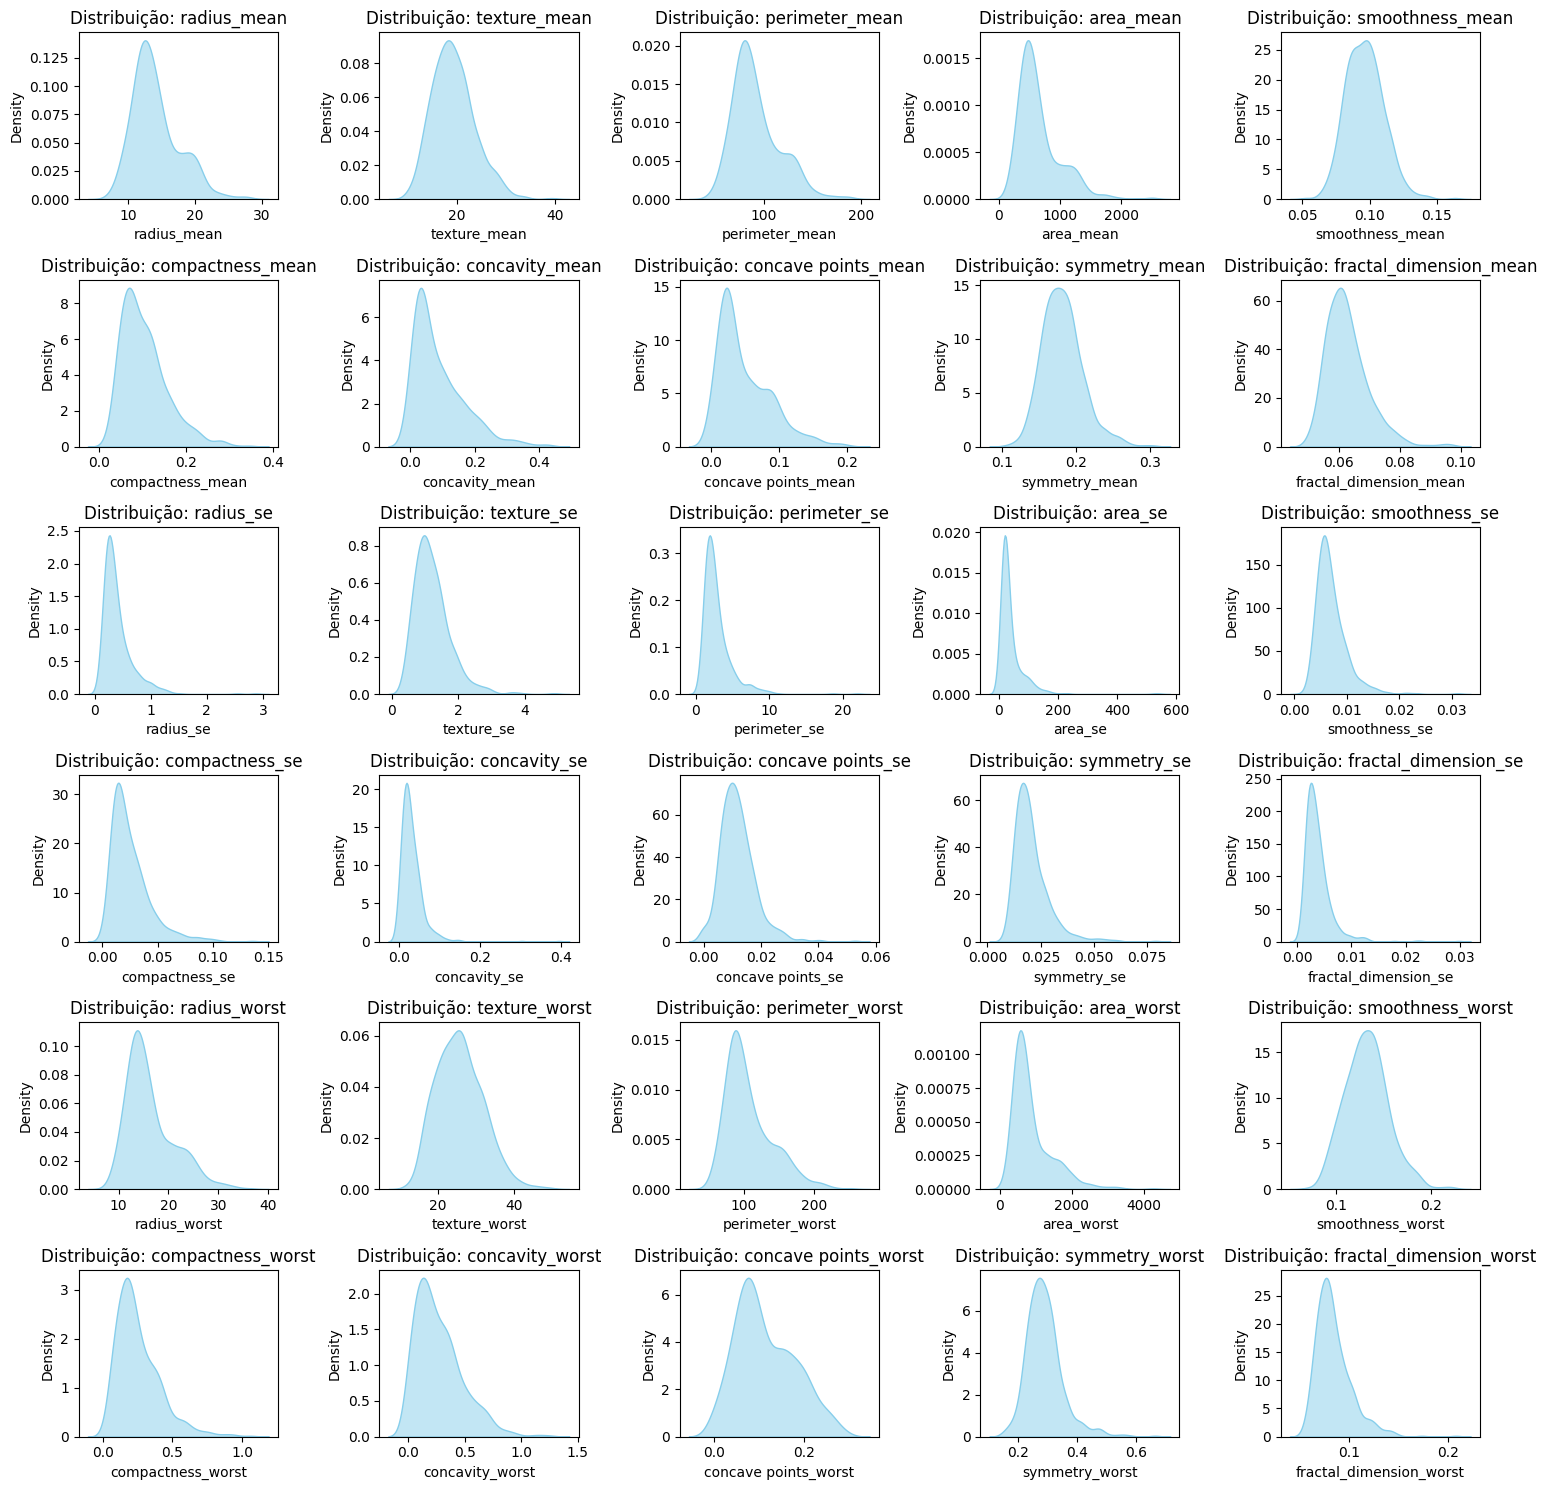

In [ ]:
features_mean = list(df_breast_cancer.columns[1:31])
plt.figure(figsize=(15, 15))

for i, feature in enumerate(features_mean):
    plt.subplot(6, 5, i + 1)
    sns.kdeplot(df_breast_cancer[feature], fill=True, color='skyblue', alpha=0.5)
    plt.title(f'Distribuição: {feature}')

plt.tight_layout()
plt.show()

### 4.3 Distribuição por Diagnóstico — Benigno vs. Maligno

A sobreposição entre as curvas de densidade de cada classe indica o poder discriminatório da feature: **quanto menor a sobreposição, maior o poder preditivo** da variável para distinguir tumores benignos de malignos.

In [ ]:
# Mapeamento de cores consistente: Benigno = verde, Maligno = vermelho
color_map = {'B': 'green', 'M': 'red'}
color_map_num = {0: 'green', 1: 'red'}

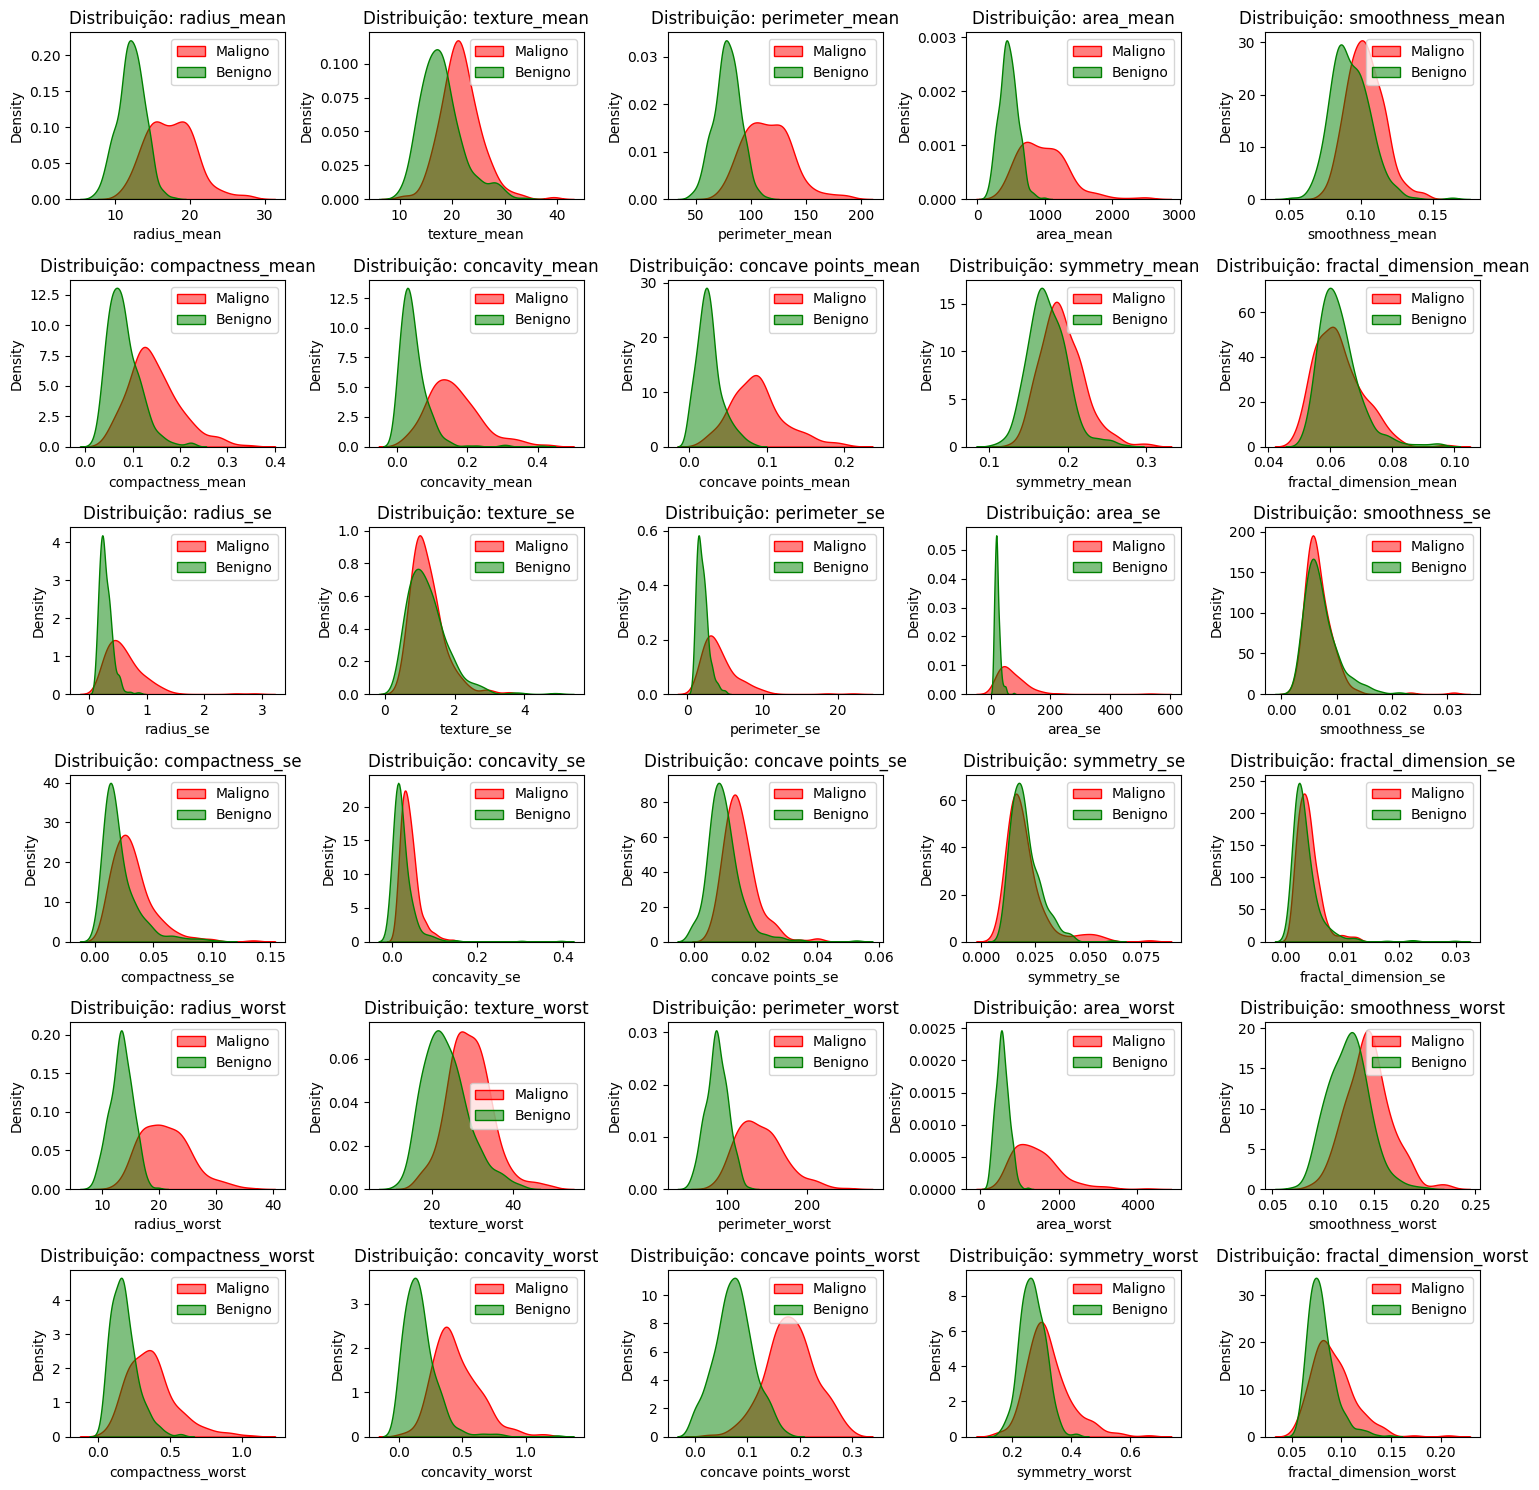

In [ ]:
features_mean = list(df_breast_cancer.columns[1:31])
plt.figure(figsize=(15, 15))

for i, feature in enumerate(features_mean):
    plt.subplot(6, 5, i + 1)
    sns.kdeplot(df_breast_cancer[df_breast_cancer['diagnosis'] == 'M'][feature],
                label='Maligno', fill=True, color=color_map['M'], alpha=0.5)
    sns.kdeplot(df_breast_cancer[df_breast_cancer['diagnosis'] == 'B'][feature],
                label='Benigno', fill=True, color=color_map['B'], alpha=0.5)
    plt.title(f'Distribuição: {feature}')
    plt.legend()

plt.tight_layout()
plt.show()

Features com **alto poder discriminatório** (pouca sobreposição entre classes): `radius_mean`, `perimeter_mean`, `area_mean`, `concavity_mean`, `concave points_mean` e todas as features do grupo `_worst`.

Features com **baixo poder discriminatório** (alta sobreposição entre classes): `texture_se`, `smoothness_se`, `fractal_dimension_se` e `symmetry_se`. Essas variáveis apresentam distribuições praticamente idênticas entre as duas classes, contribuindo pouco para o diagnóstico.

### 4.4 Boxplots — Outliers e Dispersão por Classe

Os boxplots mostram a mediana, os quartis e os valores atípicos de cada feature separados por diagnóstico. A distância entre as caixas indica o poder discriminatório da variável.

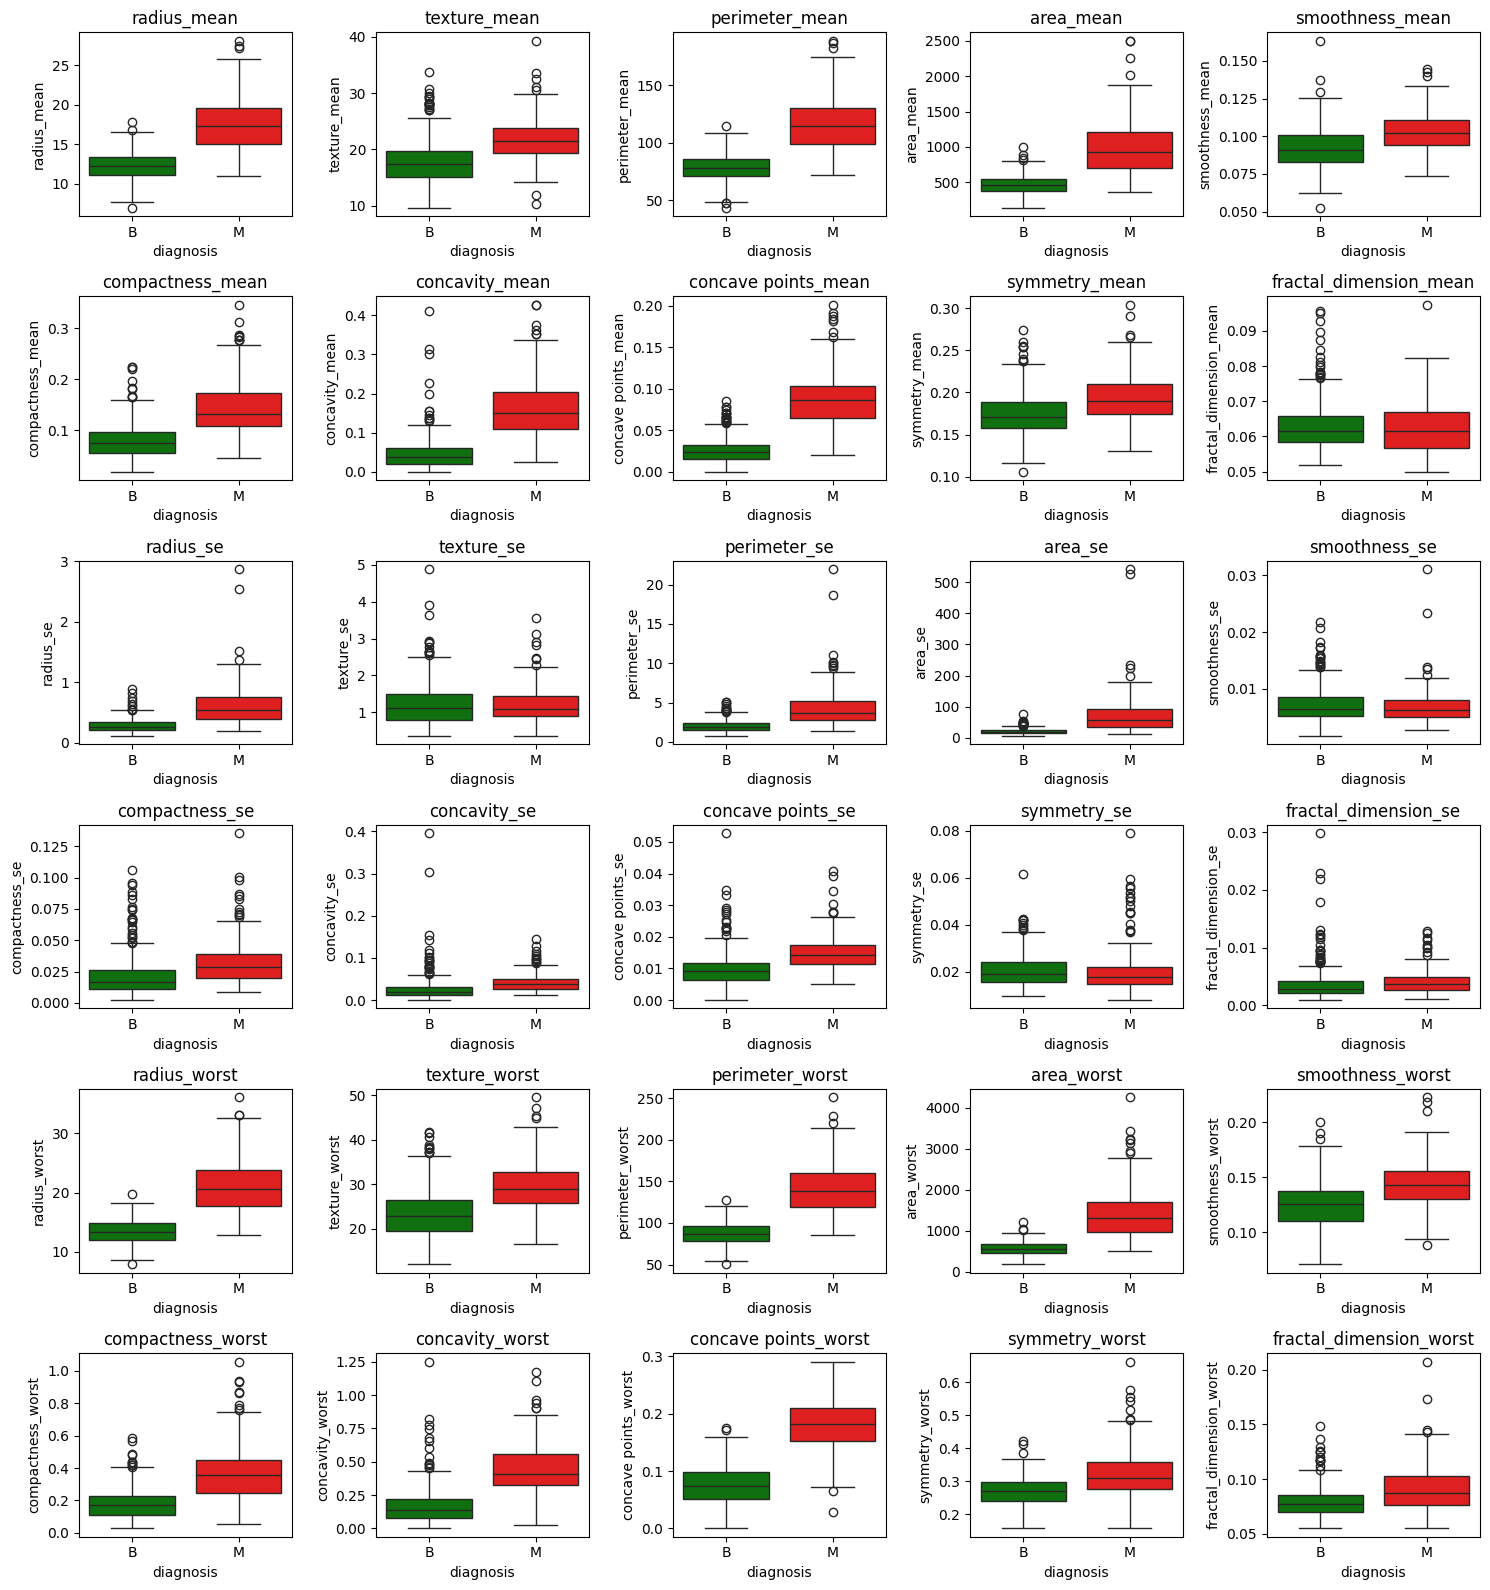

In [ ]:
cols_to_plot = df_breast_cancer.columns[1:31]

plt.figure(figsize=(15, 16))

for i, col in enumerate(cols_to_plot):
    plt.subplot(6, 5, i + 1)
    sns.boxplot(x='diagnosis', y=col, data=df_breast_cancer, patch_artist=True,
                palette=color_map, hue="diagnosis", legend=False,
                order=['B', 'M'])
    plt.title(col)

plt.tight_layout()
plt.show()

#### Interpretação dos Boxplots

- **Alta separabilidade** (medianas bem distantes entre Benigno e Maligno): `radius_mean`, `perimeter_mean`, `area_mean`, `concavity_mean`, `concave points_mean` e as respectivas features `_worst`. São as variáveis mais informativas para os classificadores.
- **Baixa separabilidade** (caixas muito sobrepostas): `texture_se`, `smoothness_se`, `fractal_dimension_se` e `symmetry_se` — confirmando a análise dos gráficos KDE.
- **Outliers**: Tumores malignos tendem a apresentar valores extremos nas features de tamanho (`area`, `perimeter`, `radius`), o que é coerente com o crescimento desordenado de células cancerígenas.
- **Features `_worst`**: Oferecem, em geral, maior separabilidade do que as features `_mean` e `_se`, sugerindo que os valores mais extremos dos núcleos celulares são os melhores indicadores de malignidade.

---
## 5. Modelagem — Conjunto Completo (30 Features)

### 5.1 Validação Cruzada (10-Fold)

Avaliamos quatro classificadores utilizando validação cruzada com 10 folds: **KNN**, **SVM**, **Random Forest** e **Regressão Logística**. As métricas calculadas em cada fold são agregadas pela média e desvio padrão.

In [ ]:
# Preparação dos dados
X = df_scaled.drop('diagnosis', axis=1)
y = df_scaled['diagnosis']

# Configuração do KFold
kfold = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

knn = KNeighborsClassifier(n_neighbors=9, metric='cosine', weights='distance')
svm = SVC(random_state=RANDOM_STATE)
rf  = RandomForestClassifier(random_state=RANDOM_STATE)
lr  = LogisticRegression(random_state=RANDOM_STATE)

scoring = ['recall', 'precision', 'f1', 'roc_auc']

# Validação cruzada
knn_result = cross_validate(knn, X, y, cv=kfold, scoring=scoring)
svm_result = cross_validate(svm, X, y, cv=kfold, scoring=scoring)
rf_result  = cross_validate(rf,  X, y, cv=kfold, scoring=scoring)
lr_result  = cross_validate(lr,  X, y, cv=kfold, scoring=scoring)

agg_knn = pd.DataFrame(knn_result).agg(['mean', 'std']).T
agg_svm = pd.DataFrame(svm_result).agg(['mean', 'std']).T
agg_rf  = pd.DataFrame(rf_result).agg(['mean', 'std']).T
agg_lr  = pd.DataFrame(lr_result).agg(['mean', 'std']).T

print('\nResultado KNN')
display(agg_knn)
print('\nResultado SVM')
display(agg_svm)
print('\nResultado Random Forest')
display(agg_rf)
print('\nResultado Regressão Logística')
display(agg_lr)


Resultado KNN


,mean,std
fit_time,0.005799,0.001808
score_time,0.041784,0.014080
test_recall,0.937459,0.064398
test_precision,0.970255,0.043110
test_f1,0.952118,0.039823
test_roc_auc,0.984667,0.017209



Resultado SVM


,mean,std
fit_time,0.013559,0.004794
score_time,0.022626,0.006924
test_recall,0.943796,0.062047
test_precision,0.969198,0.037645
test_f1,0.955855,0.046921
test_roc_auc,0.995212,0.007068



Resultado Random Forest


,mean,std
fit_time,0.363584,0.090621
score_time,0.032159,0.008598
test_recall,0.933752,0.053041
test_precision,0.963659,0.049780
test_f1,0.947151,0.036103
test_roc_auc,0.988717,0.013396



Resultado Regressão Logística


,mean,std
fit_time,0.009464,0.003034
score_time,0.018794,0.006532
test_recall,0.959585,0.039289
test_precision,0.984419,0.025158
test_f1,0.971452,0.026229
test_roc_auc,0.995528,0.008342


### 5.2 Por que ROC-AUC?

O **ROC-AUC** foi utilizado como métrica principal de comparação pelos seguintes motivos:

1. **Robusto ao desbalanceamento**: com 63% de amostras Benignas, um modelo que classificasse tudo como Benigno já atingiria 63% de acurácia — sem aprender nada. O ROC-AUC não é influenciado por essa assimetria.
2. **Relevância clínica**: em diagnóstico médico, é fundamental minimizar falsos negativos (tumores malignos não detectados). O ROC-AUC permite analisar o trade-off entre sensibilidade e especificidade de forma clara.
3. **Métrica bem estabelecida**: A métrica de ROC-AUC é amplamente utilizada no meio de data science e no meio médico.

A **Regressão Logística** apresentou o melhor ROC-AUC dentre os quatro modelos avaliados e será submetida ao ajuste de hiperparâmetros.

---
## 6. Ajuste de Hiperparâmetros — GridSearchCV

Utilizamos `GridSearchCV` para encontrar a melhor combinação de hiperparâmetros para a Regressão Logística. O método testa todas as permutações do grid definido, garantindo que a combinação ótima seja encontrada.

`StratifiedKFold` é utilizado para preservar o balanceamento das classes em cada fold durante a busca. A métrica de otimização é o ROC-AUC.

In [ ]:
param_grid = [{
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2'],
    'max_iter': [500]
}, {
    'solver': ['saga'],
    'penalty': [None],
    'max_iter': [500]
}, {
    'solver': ['lbfgs'],
    'penalty': ['l2'],
    'max_iter': [500]
}, {
    'solver': ['newton-cg', 'sag'],
    'penalty': [None, 'l2'],
    'max_iter': [500]
}, {
    'solver': ['saga'],
    'penalty': ['elasticnet'],
    'max_iter': [1000],
    'l1_ratio': np.linspace(0, 1, num=10)  # parâmetro obrigatório para elasticnet
}]

lr_model = LogisticRegression(random_state=RANDOM_STATE)

# StratifiedKFold mantém o balanceamento das classes em cada split
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(estimator=lr_model,
                           param_grid=param_grid,
                           scoring='roc_auc',
                           cv=kfold,
                           verbose=1,
                           n_jobs=-1)

grid_search.fit(X, y)

print("\nMelhores parâmetros encontrados:", grid_search.best_params_)
print("Melhor ROC-AUC (validação cruzada):", round(grid_search.best_score_, 4))

melhor_modelo_grid = grid_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhores parâmetros encontrados: {'l1_ratio': np.float64(0.6666666666666666), 'max_iter': 1000, 'penalty': 'elasticnet', 'solver': 'saga'}
Melhor ROC-AUC (validação cruzada): 0.9968


O `GridSearchCV` identificou a combinação de hiperparâmetros que maximiza o ROC-AUC. A penalidade `elasticnet` com o solver `saga`.

In [ ]:
modelo = melhor_modelo_grid

---
## 7. Avaliação Final do Modelo

O modelo com os melhores hiperparâmetros é treinado em 80% dos dados (split estratificado) e avaliado nos 20% restantes — dados que nunca foram vistos durante o treinamento ou a seleção de hiperparâmetros.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=RANDOM_STATE)

modelo.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(l1_ratio=np.float64(0.6666666666666666), max_iter=1000,
                   penalty='elasticnet', random_state=156, solver='saga')

### 7.1 Matriz de Confusão

A matriz de confusão detalha os acertos e os tipos de erro do modelo:
- **Falso Negativo (FN)**: tumor maligno classificado como benigno — o erro mais crítico em contexto clínico.
- **Falso Positivo (FP)**: tumor benigno classificado como maligno — leva a exames adicionais desnecessários, mas é menos grave.

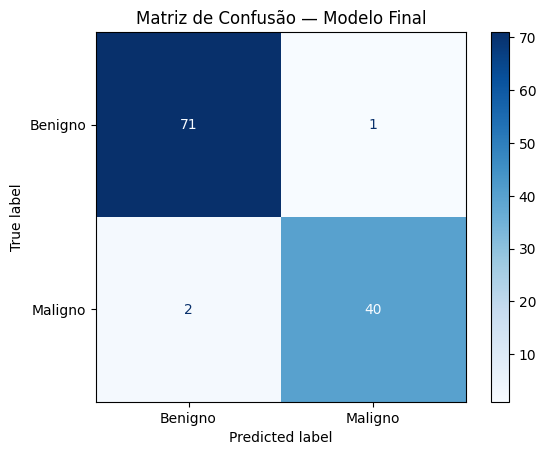

In [ ]:
y_predito = modelo.predict(X_test)

cm = confusion_matrix(y_test, y_predito)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão — Modelo Final')
plt.show()

### 7.2 Curva ROC

A curva ROC plota a Taxa de Verdadeiros Positivos (recall/sensibilidade) contra a Taxa de Falsos Positivos para todos os thresholds de classificação. A área sob a curva (AUC) resume o desempenho: valores próximos de 1.0 indicam excelente separação entre as classes.

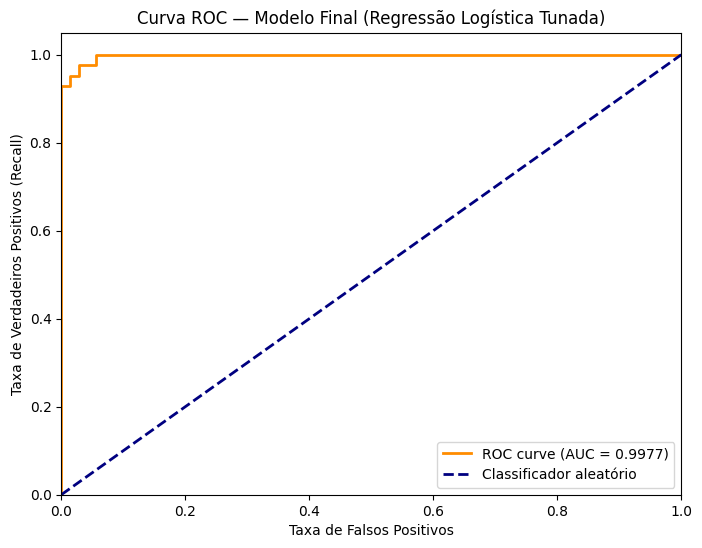

In [ ]:
# Probabilidades previstas para a classe positiva (Maligno = 1)
y_pred_proba = modelo.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classificador aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curva ROC — Modelo Final (Regressão Logística Tunada)')
plt.legend(loc='lower right')
plt.show()

### 7.3 Relatório de Classificação

Métricas detalhadas por classe: precisão, recall e F1-score.

In [ ]:
print(classification_report(y_test, y_predito, target_names=['Benigno', 'Maligno']))

              precision    recall  f1-score   support

     Benigno       0.97      0.99      0.98        72
     Maligno       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



---
## 8. Subconjunto de Features `_worst`

As features com sufixo `_worst` representam os valores máximos observados nos núcleos celulares de cada amostra. A hipótese é que as características mais extremas do tumor são as mais indicativas de malignidade.

Criamos um subconjunto contendo apenas as colunas `_worst` e a variável alvo, depois filtramos somente aquelas com **correlação absoluta ≥ 0.65** com o diagnóstico.

In [ ]:
columns_worst = [col for col in df_breast_cancer.columns if '_worst' in col or col == 'diagnosis']
df_breast_cancer_worst = df_breast_cancer[columns_worst]
display(df_breast_cancer_worst.head())

,diagnosis,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 8.1 Correlação das Features `_worst` com o Diagnóstico

Calculamos a correlação de cada feature `_worst` com a variável alvo e filtramos apenas as que apresentam correlação absoluta ≥ 0.65.

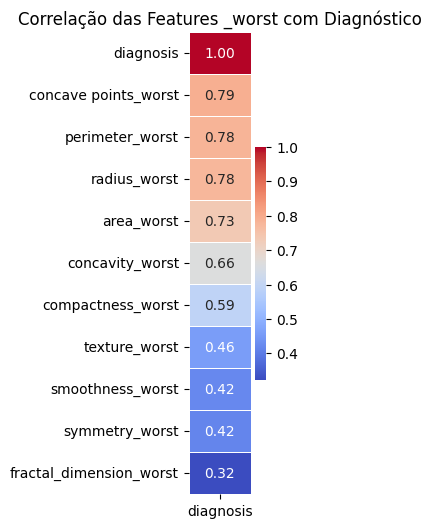

,diagnosis,concave points_worst,perimeter_worst,radius_worst,area_worst,concavity_worst
0,M,0.2654,184.60,25.380,2019.0,0.7119
1,M,0.1860,158.80,24.990,1956.0,0.2416
2,M,0.2430,152.50,23.570,1709.0,0.4504
3,M,0.2575,98.87,14.910,567.7,0.6869
4,M,0.1625,152.20,22.540,1575.0,0.4000
...,...,...,...,...,...,...
564,M,0.2216,166.10,25.450,2027.0,0.4107
565,M,0.1628,155.00,23.690,1731.0,0.3215
566,M,0.1418,126.70,18.980,1124.0,0.3403
567,M,0.2650,184.60,25.740,1821.0,0.9387


In [ ]:
# Cópia temporária com diagnosis numérico para o cálculo de correlação
df_temp_corr = df_breast_cancer_worst.copy(deep=True)
lEncoder_temp = LabelEncoder()
df_temp_corr['diagnosis'] = lEncoder_temp.fit_transform(df_temp_corr['diagnosis'])

correlation_matrix_worst = (
    df_temp_corr.select_dtypes(include=['number'])
    .corr()[['diagnosis']]
    .sort_values(by='diagnosis', ascending=False)
)

plt.figure(figsize=(1, 6))
sns.heatmap(correlation_matrix_worst, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlação das Features _worst com Diagnóstico')
plt.show()

# Selecionar features com correlação absoluta >= 0.65
corr_abs = correlation_matrix_worst['diagnosis'].abs()
relevant_cols = corr_abs[corr_abs >= 0.65].index.tolist()
if 'diagnosis' not in relevant_cols:
    relevant_cols.append('diagnosis')

df_breast_cancer_worst_filtered = df_breast_cancer_worst[relevant_cols]
display(df_breast_cancer_worst_filtered)

### 8.2 Pré-processamento das Features `_worst` Filtradas

Aplicamos `LabelEncoder` e `StandardScaler` ao subconjunto filtrado antes de treinar os modelos.

In [ ]:
lEncoder_worst = LabelEncoder()
df_num_worst = df_breast_cancer_worst_filtered.copy(deep=True)
df_num_worst['diagnosis'] = lEncoder_worst.fit_transform(df_num_worst['diagnosis'])

print("Mapeamento de Diagnóstico:")
for index, klass in enumerate(lEncoder_worst.classes_):
  print(f"  {klass} -> {index}")

X_worst = df_num_worst.drop('diagnosis', axis=1)
y_worst = df_num_worst['diagnosis']

scaler_worst = StandardScaler()
X_worst_scaled = scaler_worst.fit_transform(X_worst)

df_scaled_worst = pd.DataFrame(X_worst_scaled, columns=X_worst.columns)
df_scaled_worst['diagnosis'] = y_worst

print("\nPrimeiras 5 linhas do dataset filtrado e normalizado:")
display(df_scaled_worst.head())

Mapeamento de Diagnóstico:
  B -> 0
  M -> 1

Primeiras 5 linhas do dataset filtrado e normalizado:


,concave points_worst,perimeter_worst,radius_worst,area_worst,concavity_worst,diagnosis
0,2.296076,2.303601,1.886690,2.001237,2.109526,1
1,1.087084,1.535126,1.805927,1.890489,-0.146749,1
2,1.955000,1.347475,1.511870,1.456285,0.854974,1
3,2.175786,-0.249939,-0.281464,-0.550021,1.989588,1
4,0.729259,1.338539,1.298575,1.220724,0.613179,1


### 8.3 Validação Cruzada com Features `_worst` Filtradas

Treinamos os mesmos quatro classificadores com o subconjunto reduzido para comparar o desempenho com o conjunto completo de 30 features.

In [ ]:
X_filtered = df_scaled_worst.drop('diagnosis', axis=1)
y_filtered = df_scaled_worst['diagnosis']

kfold = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

knn_f = KNeighborsClassifier(n_neighbors=9, metric='cosine', weights='distance')
svm_f = SVC(random_state=RANDOM_STATE)
rf_f  = RandomForestClassifier(random_state=RANDOM_STATE)
lr_f  = LogisticRegression(random_state=RANDOM_STATE)

knn_result_f = cross_validate(knn_f, X_filtered, y_filtered, cv=kfold, scoring=scoring)
svm_result_f = cross_validate(svm_f, X_filtered, y_filtered, cv=kfold, scoring=scoring)
rf_result_f  = cross_validate(rf_f,  X_filtered, y_filtered, cv=kfold, scoring=scoring)
lr_result_f  = cross_validate(lr_f,  X_filtered, y_filtered, cv=kfold, scoring=scoring)

agg_knn_f = pd.DataFrame(knn_result_f).agg(['mean', 'std']).T
agg_svm_f = pd.DataFrame(svm_result_f).agg(['mean', 'std']).T
agg_rf_f  = pd.DataFrame(rf_result_f).agg(['mean', 'std']).T
agg_lr_f  = pd.DataFrame(lr_result_f).agg(['mean', 'std']).T

print('\nResultado KNN (Features _worst Filtradas)')
display(agg_knn_f)
print('\nResultado SVM (Features _worst Filtradas)')
display(agg_svm_f)
print('\nResultado Random Forest (Features _worst Filtradas)')
display(agg_rf_f)
print('\nResultado Regressão Logística (Features _worst Filtradas)')
display(agg_lr_f)


Resultado KNN (Features _worst Filtradas)


,mean,std
fit_time,0.002246,0.000171
score_time,0.015708,0.001233
test_recall,0.947677,0.032960
test_precision,0.933604,0.072337
test_f1,0.938293,0.030270
test_roc_auc,0.977865,0.016366



Resultado SVM (Features _worst Filtradas)


,mean,std
fit_time,0.004804,0.000248
score_time,0.012517,0.000846
test_recall,0.918018,0.069158
test_precision,0.943446,0.056756
test_f1,0.928478,0.044771
test_roc_auc,0.986392,0.014854



Resultado Random Forest (Features _worst Filtradas)


,mean,std
fit_time,0.209343,0.007692
score_time,0.029183,0.003825
test_recall,0.908373,0.054144
test_precision,0.923680,0.056829
test_f1,0.914312,0.037461
test_roc_auc,0.981454,0.019788



Resultado Regressão Logística (Features _worst Filtradas)


,mean,std
fit_time,0.006629,0.000561
score_time,0.015455,0.001013
test_recall,0.928544,0.059157
test_precision,0.934435,0.059498
test_f1,0.929468,0.038561
test_roc_auc,0.989204,0.015193


---
## 9. Conclusão

| Aspecto | Resultado |
|---|---|
| Melhor modelo | Regressão Logística (`solver=saga`, `penalty=elasticnet`) |
| ROC-AUC (validação cruzada) | **0.9968** |
| Acurácia (conjunto de teste) | **97%** |
| Recall — classe maligna (teste) | **95%** |
| Melhor subconjunto de features | 30 features completas |
| Subconjunto `_worst` (5 features) | ROC-AUC ~0.989 — excelente com apenas 5 features |

### Principais Aprendizados

1. **Regressão Logística supera modelos mais complexos** após ajuste de hiperparâmetros, indicando que a relação entre features e diagnóstico é razoavelmente linear no espaço normalizado.

2. **ROC-AUC é a métrica mais adequada** para datasets com desbalanceamento moderado (63/37). A acurácia pode ser enganosa nesses contextos.

3. **Apenas 5 features `_worst` mantêm desempenho excelente** — aproximadamente 0.6 a 0.9 pontos percentuais abaixo do conjunto completo. Em cenários com coleta de dados limitada, focar nas características mais extremas dos núcleos celulares é suficiente.

### Considerações finais

Vale ressaltar que este estudo coloca em questão a viabilidade do desenvolvimento de um sistema baseado em machine learn que seja usado como uma ferramenta auxiliar no diagnóstico de câncer de mama.

Entende-se que o uso desta ferramenta seria sempre como acompanhamento do processo clínico tradicional, trazendo agilidade para o processo, mas com a supervisão dos responsáveis da área.